# Assignment 2 – Learning Strategy (MNIST, Keras)
Nama: **Nabila Hermawan** | NIM: **25/572261/PPA/07190**

Isi: (1) replikasi kode MNIST dari slide, (2) eksperimen L1, L2, Dropout, Early Stopping, L1+Dropout.
Jalankan semua cell dari atas ke bawah (Runtime > Run all).

## 0. Import & Load Data (slide 14)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Input, Flatten, Dense, Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping

keras.utils.set_random_seed(42)   # supaya hasil bisa direproduksi

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255
X_test  = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255
y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

# Sesuai slide 13: 55.000 train, 5.000 validasi, 10.000 test
X_val, y_val = X_train[55000:], y_train[55000:]
X_train, y_train = X_train[:55000], y_train[:55000]
print(X_train.shape, X_val.shape, X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(55000, 28, 28, 1) (5000, 28, 28, 1) (10000, 28, 28, 1)


## Fungsi bantu (bangun model, latih, plot, evaluasi)

In [ ]:
results = {}   # menyimpan ringkasan tiap skenario

def build_model(l1=0.0, l2=0.0, dropout=0.0):
    reg = regularizers.L1L2(l1=l1, l2=l2) if (l1 or l2) else None
    m = Sequential()
    m.add(Input(shape=(28, 28, 1)))
    m.add(Flatten())
    m.add(Dense(64, activation='relu', kernel_regularizer=reg))
    if dropout > 0:
        m.add(Dropout(dropout))
    m.add(Dense(10, activation='softmax'))
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    return m

def run(name, model, epochs=10, callbacks=None):
    model.summary()
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=100,
                        validation_data=(X_val, y_val), callbacks=callbacks, verbose=2)
    model.save(f'{name}.keras')
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    h = history.history
    n = len(h['loss'])
    print(f'\n[{name}] epoch dijalankan: {n} | test loss: {test_loss:.4f} | test acc: {test_acc:.4f}')

    ep = range(1, n + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(ep, h['loss'], 'r', label='training loss')
    ax[0].plot(ep, h['val_loss'], 'b', label='validation loss')
    ax[0].set_title(f'Loss - {name}'); ax[0].set_xlabel('epoch'); ax[0].legend()
    ax[1].plot(ep, h['acc'], 'r', label='training acc')
    ax[1].plot(ep, h['val_acc'], 'b', label='validation acc')
    ax[1].set_title(f'Accuracy - {name}'); ax[1].set_xlabel('epoch'); ax[1].legend()
    plt.tight_layout(); plt.savefig(f'{name}_curves.png', dpi=150); plt.show()

    results[name] = dict(epochs=n, train_acc=h['acc'][-1], val_acc=h['val_acc'][-1],
                         train_loss=h['loss'][-1], val_loss=h['val_loss'][-1],
                         test_acc=test_acc, test_loss=test_loss)
    return history

## 1. Baseline (replikasi slide 15–23)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
550/550 - 7s - 12ms/step - acc: 0.8850 - loss: 0.4162 - val_acc: 0.9488 - val_loss: 0.1881
Epoch 2/10
550/550 - 2s - 4ms/step - acc: 0.9406 - loss: 0.2072 - val_acc: 0.9620 - val_loss: 0.1413
Epoch 3/10
550/550 - 2s - 3ms/step - acc: 0.9544 - loss: 0.1554 - val_acc: 0.9684 - val_loss: 0.1191
Epoch 4/10
550/550 - 2s - 3ms/step - acc: 0.9641 - loss: 0.1248 - val_acc: 0.9720 - val_loss: 0.1069
Epoch 5/10
550/550 - 2s - 3ms/step - acc: 0.9705 - loss: 0.1042 - val_acc: 0.9730 - val_loss: 0.0997
Epoch 6/10
550/550 - 3s - 5ms/step - acc: 0.9750 - loss: 0.0890 - val_acc: 0.9734 - val_loss: 0.0945
Epoch 7/10
550/550 - 4s - 7ms/step - acc: 0.9785 - loss: 0.0775 - val_acc: 0.9732 - val_loss: 0.0916
Epoch 8/10
550/550 - 2s - 3ms/step - acc: 0.9810 - loss: 0.0682 - val_acc: 0.9734 - val_loss: 0.0906
Epoch 9/10
550/550 - 2s - 4ms/step - acc: 0.9830 - loss: 0.0605 - val_acc: 0.9724 - val_loss: 0.0909
Epoch 10/10
550/550 - 3s - 5ms/step - acc: 0.9851 - loss: 0.0540 - val_acc: 0.9712 - val_l

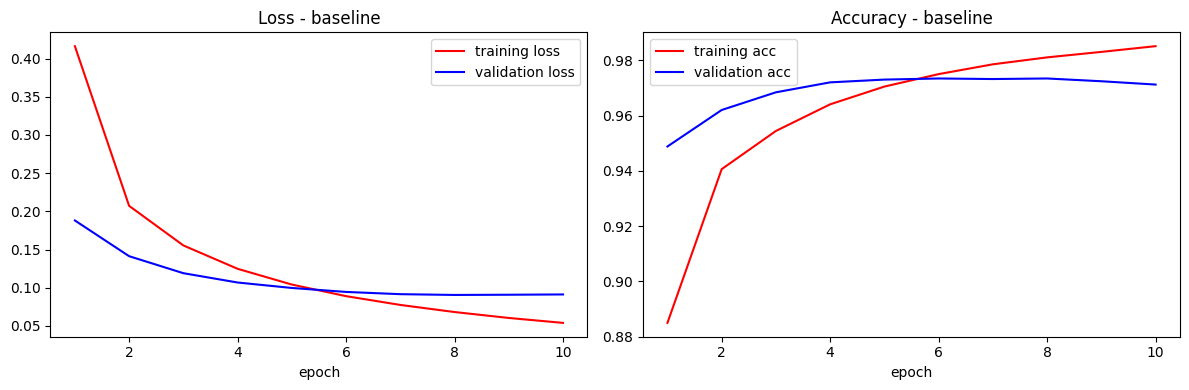

In [ ]:
model1 = build_model()
history1 = run('baseline', model1, epochs=10)

In [ ]:
# Load model & prediksi (slide 23)
from keras.models import load_model
model_simpan = load_model('baseline.keras')
pred = model_simpan.predict(X_test)
print('label actual    :', np.argmax(y_test[30]))
print('label prediction:', np.argmax(pred[30]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
label actual    : 3
label prediction: 3


## 2a. L1 Regularization (rate = 0.0001)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
550/550 - 4s - 7ms/step - acc: 0.8862 - loss: 0.5446 - val_acc: 0.9494 - val_loss: 0.3073
Epoch 2/10
550/550 - 2s - 3ms/step - acc: 0.9395 - loss: 0.3260 - val_acc: 0.9616 - val_loss: 0.2541
Epoch 3/10
550/550 - 2s - 3ms/step - acc: 0.9515 - loss: 0.2746 - val_acc: 0.9684 - val_loss: 0.2272
Epoch 4/10
550/550 - 2s - 3ms/step - acc: 0.9588 - loss: 0.2437 - val_acc: 0.9714 - val_loss: 0.2100
Epoch 5/10
550/550 - 2s - 3ms/step - acc: 0.9640 - loss: 0.2227 - val_acc: 0.9740 - val_loss: 0.1971
Epoch 6/10
550/550 - 2s - 3ms/step - acc: 0.9674 - loss: 0.2077 - val_acc: 0.9768 - val_loss: 0.1874
Epoch 7/10
550/550 - 4s - 7ms/step - acc: 0.9703 - loss: 0.1962 - val_acc: 0.9774 - val_loss: 0.1801
Epoch 8/10
550/550 - 2s - 3ms/step - acc: 0.9723 - loss: 0.1871 - val_acc: 0.9782 - val_loss: 0.1749
Epoch 9/10
550/550 - 2s - 3ms/step - acc: 0.9740 - loss: 0.1796 - val_acc: 0.9790 - val_loss: 0.1708
Epoch 10/10
550/550 - 2s - 3ms/step - acc: 0.9753 - loss: 0.1734 - val_acc: 0.9786 - val_lo

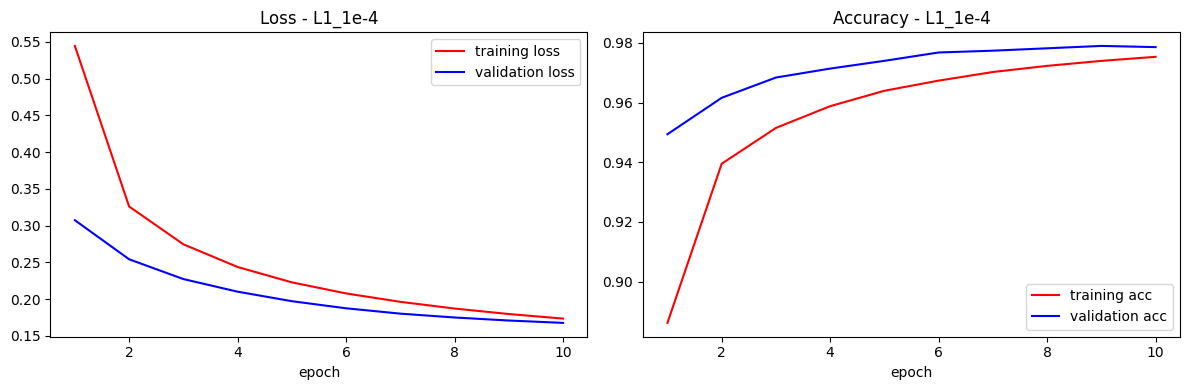

In [ ]:
model_l1 = build_model(l1=1e-4)
h_l1 = run('L1_1e-4', model_l1, epochs=10)

## 2b. L2 Regularization (rate = 0.001)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
550/550 - 3s - 6ms/step - acc: 0.8832 - loss: 0.5070 - val_acc: 0.9458 - val_loss: 0.2794
Epoch 2/10
550/550 - 3s - 5ms/step - acc: 0.9358 - loss: 0.3034 - val_acc: 0.9586 - val_loss: 0.2321
Epoch 3/10
550/550 - 2s - 3ms/step - acc: 0.9475 - loss: 0.2545 - val_acc: 0.9650 - val_loss: 0.2055
Epoch 4/10
550/550 - 2s - 3ms/step - acc: 0.9556 - loss: 0.2241 - val_acc: 0.9684 - val_loss: 0.1891
Epoch 5/10
550/550 - 2s - 3ms/step - acc: 0.9612 - loss: 0.2041 - val_acc: 0.9706 - val_loss: 0.1775
Epoch 6/10
550/550 - 2s - 3ms/step - acc: 0.9648 - loss: 0.1900 - val_acc: 0.9716 - val_loss: 0.1691
Epoch 7/10
550/550 - 2s - 3ms/step - acc: 0.9669 - loss: 0.1792 - val_acc: 0.9732 - val_loss: 0.1634
Epoch 8/10
550/550 - 3s - 5ms/step - acc: 0.9691 - loss: 0.1706 - val_acc: 0.9744 - val_loss: 0.1583
Epoch 9/10
550/550 - 2s - 4ms/step - acc: 0.9707 - loss: 0.1635 - val_acc: 0.9748 - val_loss: 0.1546
Epoch 10/10
550/550 - 2s - 3ms/step - acc: 0.9724 - loss: 0.1574 - val_acc: 0.9756 - val_lo

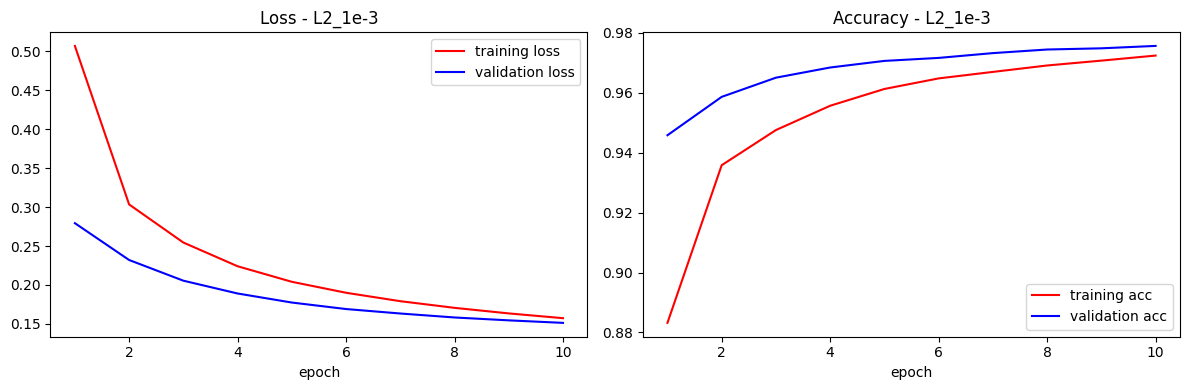

In [ ]:
model_l2 = build_model(l2=1e-3)
h_l2 = run('L2_1e-3', model_l2, epochs=10)

## 2c. Dropout (rate = 0.3)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
550/550 - 3s - 5ms/step - acc: 0.8438 - loss: 0.5321 - val_acc: 0.9470 - val_loss: 0.1924
Epoch 2/10
550/550 - 2s - 3ms/step - acc: 0.9186 - loss: 0.2806 - val_acc: 0.9616 - val_loss: 0.1439
Epoch 3/10
550/550 - 3s - 6ms/step - acc: 0.9334 - loss: 0.2292 - val_acc: 0.9674 - val_loss: 0.1216
Epoch 4/10
550/550 - 2s - 3ms/step - acc: 0.9420 - loss: 0.1993 - val_acc: 0.9696 - val_loss: 0.1088
Epoch 5/10
550/550 - 2s - 3ms/step - acc: 0.9467 - loss: 0.1794 - val_acc: 0.9708 - val_loss: 0.0983
Epoch 6/10
550/550 - 2s - 3ms/step - acc: 0.9508 - loss: 0.1628 - val_acc: 0.9732 - val_loss: 0.0923
Epoch 7/10
550/550 - 2s - 3ms/step - acc: 0.9539 - loss: 0.1524 - val_acc: 0.9730 - val_loss: 0.0928
Epoch 8/10
550/550 - 2s - 3ms/step - acc: 0.9550 - loss: 0.1424 - val_acc: 0.9736 - val_loss: 0.0882
Epoch 9/10
550/550 - 3s - 5ms/step - acc: 0.9589 - loss: 0.1354 - val_acc: 0.9742 - val_loss: 0.0856
Epoch 10/10
550/550 - 2s - 4ms/step - acc: 0.9612 - loss: 0.1274 - val_acc: 0.9750 - val_lo

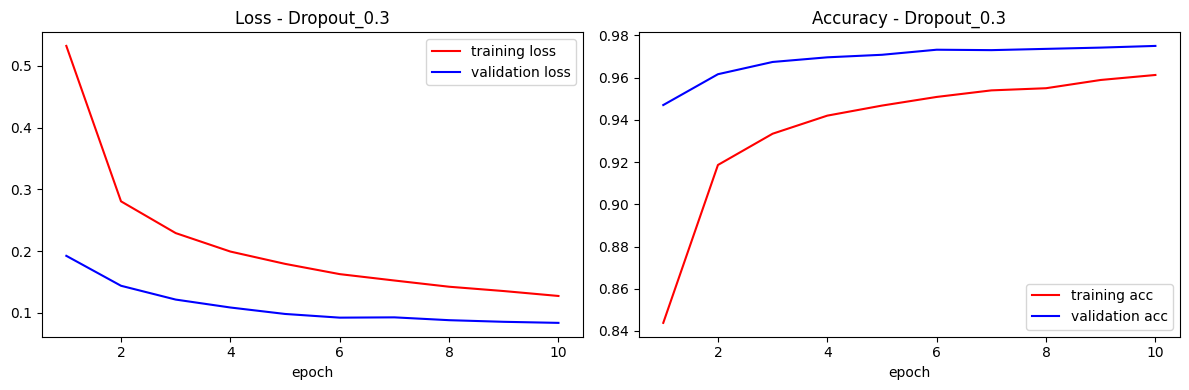

In [ ]:
model_do = build_model(dropout=0.3)
h_do = run('Dropout_0.3', model_do, epochs=10)

## 2d. Early Stopping (monitor val_loss, patience = 3, epochs maks 50)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
550/550 - 3s - 6ms/step - acc: 0.8911 - loss: 0.4057 - val_acc: 0.9542 - val_loss: 0.1753
Epoch 2/50
550/550 - 2s - 3ms/step - acc: 0.9447 - loss: 0.1923 - val_acc: 0.9660 - val_loss: 0.1326
Epoch 3/50
550/550 - 3s - 5ms/step - acc: 0.9585 - loss: 0.1443 - val_acc: 0.9696 - val_loss: 0.1133
Epoch 4/50
550/550 - 3s - 5ms/step - acc: 0.9664 - loss: 0.1158 - val_acc: 0.9724 - val_loss: 0.1023
Epoch 5/50
550/550 - 2s - 3ms/step - acc: 0.9719 - loss: 0.0962 - val_acc: 0.9750 - val_loss: 0.0961
Epoch 6/50
550/550 - 2s - 3ms/step - acc: 0.9766 - loss: 0.0817 - val_acc: 0.9750 - val_loss: 0.0927
Epoch 7/50
550/550 - 2s - 3ms/step - acc: 0.9798 - loss: 0.0706 - val_acc: 0.9746 - val_loss: 0.0911
Epoch 8/50
550/550 - 2s - 3ms/step - acc: 0.9829 - loss: 0.0617 - val_acc: 0.9740 - val_loss: 0.0898
Epoch 9/50
550/550 - 2s - 4ms/step - acc: 0.9851 - loss: 0.0542 - val_acc: 0.9750 - val_loss: 0.0890
Epoch 10/50
550/550 - 4s - 7ms/step - acc: 0.9869 - loss: 0.0478 - val_acc: 0.9756 - val_lo

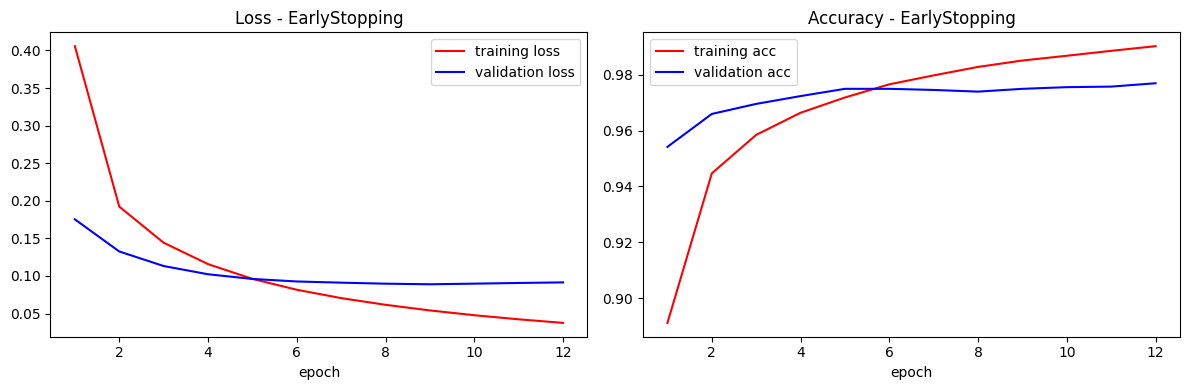

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_es = build_model()
h_es = run('EarlyStopping', model_es, epochs=50, callbacks=[es])

## 2e. L1 Regularization + Dropout (L1 = 0.0001, dropout = 0.3)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
550/550 - 3s - 5ms/step - acc: 0.8433 - loss: 0.6709 - val_acc: 0.9458 - val_loss: 0.3266
Epoch 2/10
550/550 - 2s - 4ms/step - acc: 0.9134 - loss: 0.4193 - val_acc: 0.9604 - val_loss: 0.2709
Epoch 3/10
550/550 - 3s - 5ms/step - acc: 0.9280 - loss: 0.3612 - val_acc: 0.9664 - val_loss: 0.2405
Epoch 4/10
550/550 - 2s - 3ms/step - acc: 0.9352 - loss: 0.3311 - val_acc: 0.9698 - val_loss: 0.2262
Epoch 5/10
550/550 - 2s - 3ms/step - acc: 0.9396 - loss: 0.3132 - val_acc: 0.9710 - val_loss: 0.2170
Epoch 6/10
550/550 - 2s - 3ms/step - acc: 0.9441 - loss: 0.2947 - val_acc: 0.9716 - val_loss: 0.2087
Epoch 7/10
550/550 - 2s - 4ms/step - acc: 0.9449 - loss: 0.2856 - val_acc: 0.9740 - val_loss: 0.1995
Epoch 8/10
550/550 - 2s - 3ms/step - acc: 0.9476 - loss: 0.2765 - val_acc: 0.9754 - val_loss: 0.1940
Epoch 9/10
550/550 - 4s - 7ms/step - acc: 0.9486 - loss: 0.2724 - val_acc: 0.9746 - val_loss: 0.1905
Epoch 10/10
550/550 - 2s - 3ms/step - acc: 0.9490 - loss: 0.2663 - val_acc: 0.9732 - val_lo

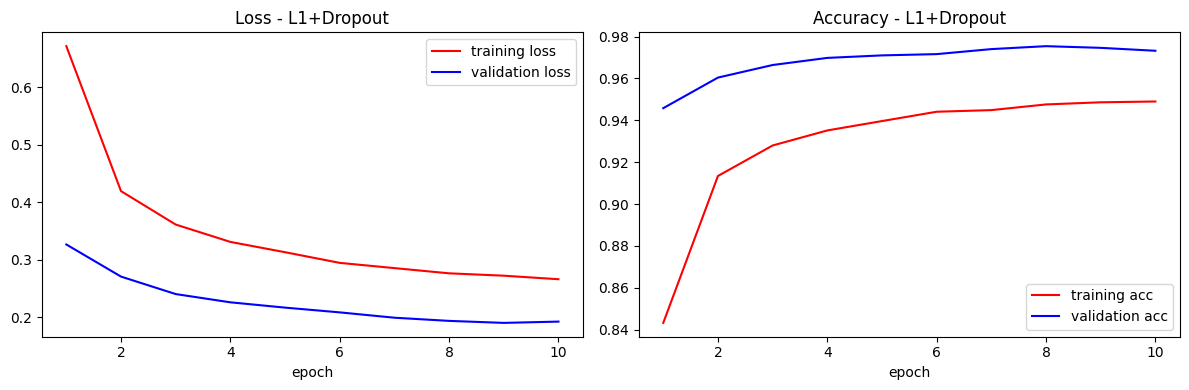

In [ ]:
model_l1do = build_model(l1=1e-4, dropout=0.3)
h_l1do = run('L1+Dropout', model_l1do, epochs=10)

## Ringkasan perbandingan (untuk slide Kesimpulan)

               epochs  train_acc  val_acc  test_acc  train_loss  val_loss  test_loss  gap_acc (train-val)
baseline         10.0     0.9851   0.9712    0.9738      0.0540    0.0913     0.0932               0.0139
L1_1e-4          10.0     0.9753   0.9786    0.9719      0.1734    0.1676     0.1780              -0.0033
L2_1e-3          10.0     0.9724   0.9756    0.9697      0.1574    0.1514     0.1582              -0.0032
Dropout_0.3      10.0     0.9612   0.9750    0.9696      0.1274    0.0839     0.0991              -0.0138
EarlyStopping    12.0     0.9903   0.9770    0.9722      0.0376    0.0915     0.0921               0.0133
L1+Dropout       10.0     0.9490   0.9732    0.9692      0.2663    0.1927     0.2022              -0.0242


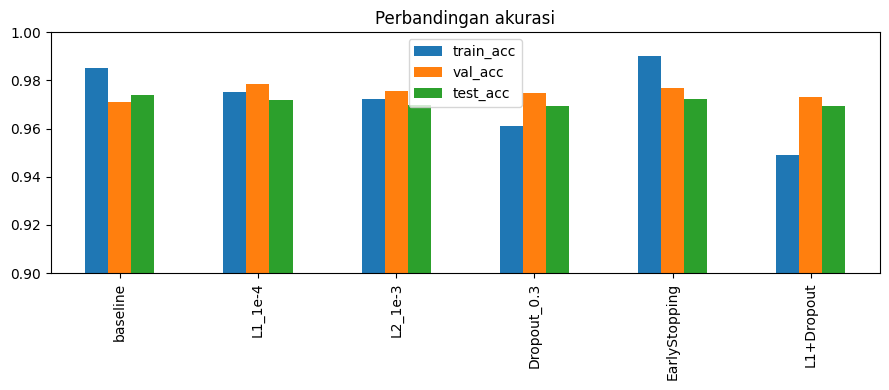

In [ ]:
import pandas as pd
df = pd.DataFrame(results).T[['epochs','train_acc','val_acc','test_acc','train_loss','val_loss','test_loss']]
df['gap_acc (train-val)'] = df['train_acc'] - df['val_acc']
print(df.round(4).to_string())
df.round(4).to_csv('ringkasan_hasil.csv')

ax = df[['train_acc','val_acc','test_acc']].plot.bar(figsize=(9,4), ylim=(0.9,1.0))
ax.set_title('Perbandingan akurasi'); plt.tight_layout(); plt.savefig('perbandingan.png', dpi=150); plt.show()

In [ ]:
# Unduh semua gambar & file hasil (Colab) untuk ditaruh di slide
import glob, shutil
shutil.make_archive('hasil_assignment2', 'zip', '.', None) if False else None
from google.colab import files
for f in glob.glob('*_curves.png') + ['perbandingan.png', 'ringkasan_hasil.csv']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>